In [1]:
pip install pandas numpy nltk spacy scikit-learn matplotlib seaborn

   ---------------------------------------- 0.0/14.2 MB ? eta -:--:--
    --------------------------------------- 0.3/14.2 MB ? eta -:--:--
   - -------------------------------------- 0.5/14.2 MB 1.8 MB/s eta 0:00:08
   -- ------------------------------------- 1.0/14.2 MB 2.2 MB/s eta 0:00:07
   ----- ---------------------------------- 1.8/14.2 MB 2.6 MB/s eta 0:00:05
   ------- -------------------------------- 2.6/14.2 MB 2.8 MB/s eta 0:00:05
   ---------- ----------------------------- 3.7/14.2 MB 3.2 MB/s eta 0:00:04
   ------------- -------------------------- 4.7/14.2 MB 3.5 MB/s eta 0:00:03
   ---------------- ----------------------- 6.0/14.2 MB 3.9 MB/s eta 0:00:03
   ------------------- -------------------- 7.1/14.2 MB 4.1 MB/s eta 0:00:02
   ----------------------- ---------------- 8.4/14.2 MB 4.3 MB/s eta 0:00:02
   -------------------------- ------------- 9.4/14.2 MB 4.4 MB/s eta 0:00:02
   ----------------------------- ---------- 10.5/14.2 MB 4.5 MB/s eta 0:00:01
   ---------

In [2]:
import nltk

nltk.download('stopwords')
nltk.download('punkt')

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\rodda\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\rodda\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping tokenizers\punkt.zip.


True

In [3]:
import pandas as pd

resume_df = pd.read_csv("Resume.csv")

resume_df.head()

,ID,Resume_str,Resume_html,Category
0,16852973,HR ADMINISTRATOR/MARKETING ASSOCIATE\...,"<div class=""fontsize fontface vmargins hmargin...",HR
1,22323967,"HR SPECIALIST, US HR OPERATIONS ...","<div class=""fontsize fontface vmargins hmargin...",HR
2,33176873,HR DIRECTOR Summary Over 2...,"<div class=""fontsize fontface vmargins hmargin...",HR
3,27018550,HR SPECIALIST Summary Dedica...,"<div class=""fontsize fontface vmargins hmargin...",HR
4,17812897,HR MANAGER Skill Highlights ...,"<div class=""fontsize fontface vmargins hmargin...",HR


In [14]:
import re
from nltk.corpus import stopwords

stop_words = set(stopwords.words('english'))

def clean_text(text):

    text = str(text).lower()

    text = re.sub(r'[^a-zA-Z ]', ' ', text)

    words = text.split()

    words = [w for w in words if w not in stop_words]

    return " ".join(words)

resume_df["clean_resume"] = (
    resume_df["Resume_str"]
    .apply(clean_text)
)
resume_df[['Resume_str','clean_resume']].head()

,Resume_str,clean_resume
0,HR ADMINISTRATOR/MARKETING ASSOCIATE\...,hr administrator marketing associate hr admini...
1,"HR SPECIALIST, US HR OPERATIONS ...",hr specialist us hr operations summary versati...
2,HR DIRECTOR Summary Over 2...,hr director summary years experience recruitin...
3,HR SPECIALIST Summary Dedica...,hr specialist summary dedicated driven dynamic...
4,HR MANAGER Skill Highlights ...,hr manager skill highlights hr skills hr depar...


In [15]:
skills = [
    "python",
    "java",
    "sql",
    "machine learning",
    "deep learning",
    "nlp",
    "tensorflow",
    "pandas",
    "numpy",
    "tableau",
    "power bi",
    "aws",
    "excel"
]

def extract_skills(text):

    found = []

    for skill in skills:
        if skill in text:
            found.append(skill)

    return found

resume_df["skills"] = (
    resume_df["clean_resume"]
    .apply(extract_skills)
)
resume_df[['Category','skills']].head()

,Category,skills
0,HR,[aws]
1,HR,[]
2,HR,[excel]
3,HR,[excel]
4,HR,"[aws, excel]"


In [16]:
job_description = """
Looking for a Machine Learning Intern
with Python, SQL, Pandas, NumPy,
Machine Learning, Data Analysis
and NLP skills.
"""
print(job_description)


Looking for a Machine Learning Intern
with Python, SQL, Pandas, NumPy,
Machine Learning, Data Analysis
and NLP skills.



In [7]:
from sklearn.feature_extraction.text import TfidfVectorizer

documents = [job_description]

documents.extend(
    list(resume_df["clean_resume"])
)

vectorizer = TfidfVectorizer()

tfidf_matrix = vectorizer.fit_transform(documents)

In [8]:
from sklearn.metrics.pairwise import cosine_similarity

similarities = cosine_similarity(
    tfidf_matrix[0:1],
    tfidf_matrix[1:]
)

resume_df["match_score"] = (
    similarities.flatten()*100
)

In [9]:
ranked_df = resume_df.sort_values(
    by="match_score",
    ascending=False
)

In [10]:
ranked_df[
    ["ID","Category","match_score"]
].head(10)

,ID,Category,match_score
2153,34953092,BANKING,13.982334
1762,12011623,ENGINEERING,13.437066
1339,18448085,AUTOMOBILE,13.256287
926,62994611,AGRICULTURE,12.405512
1218,21156767,CONSULTANT,9.742916
2291,12777487,ARTS,9.733725
1142,30863060,CONSULTANT,9.000525
194,18835363,DESIGNER,8.570895
1348,22946204,AUTOMOBILE,8.326269
374,36206485,TEACHER,7.626213


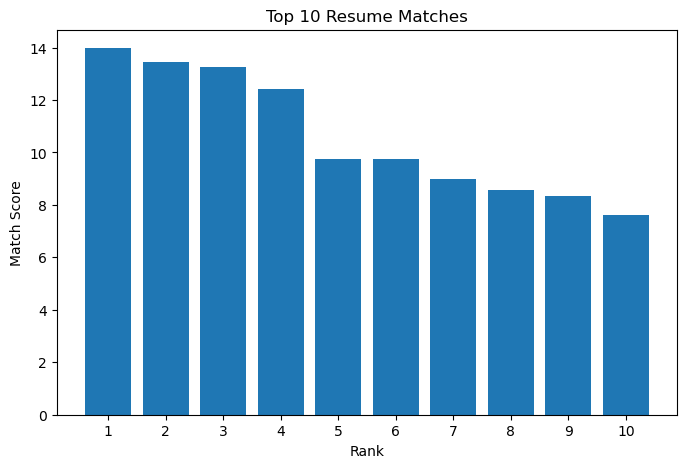

In [21]:
import matplotlib.pyplot as plt

top10 = ranked_df.head(10)

plt.figure(figsize=(8,5))

plt.bar(
    range(1, 11),
    top10["match_score"]
)

plt.xlabel("Rank")
plt.ylabel("Match Score")
plt.title("Top 10 Resume Matches")

plt.xticks(range(1, 11))

plt.show()

In [20]:
jd_skills = extract_skills(job_description)

def missing_skills(candidate_skills):

    return list(
        set(jd_skills) -
        set(candidate_skills)
    )

ranked_df["missing_skills"] = (
    ranked_df["skills"]
    .apply(missing_skills)
)


In [18]:
ranked_df.to_csv(
    "ranked_candidates.csv",
    index=False
)


In [13]:
import pickle

with open(
    "tfidf_vectorizer.pkl",
    "wb"
) as f:
    pickle.dump(vectorizer, f)